In [1]:
# Importa a biblioteca Pandas com o apelido pd para trabalhar com tabelas e dados estruturados
import pandas as pd


In [2]:
# Carrega o arquivo CSV de inadimplência da pasta 'dados' e armazena em um DataFrame chamado 'dados'
dados = pd.read_csv('dados/dados_inadimplencia.csv')

# 2. Exibe as 5 primeiras linhas do DataFrame para você visualizar a estrutura e os nomes das colunas
dados.head()


,receita_cliente,anuidade_emprestimo,anos_casa_propria,telefone_trab,avaliacao_cidade,score_1,score_2,score_3,score_social,troca_telefone,inadimplente
0,16855.246324,2997.000000,12.157324,0,2.0,0.501213,0.003109,0.513171,0.117428,243.0,1
1,13500.000000,2776.050000,12.157324,0,2.0,0.501213,0.269730,0.513171,0.097900,617.0,0
2,11250.000000,2722.188351,12.157324,0,3.0,0.701396,0.518625,0.700184,0.118600,9.0,0
3,27000.000000,6750.000000,3.000000,0,2.0,0.501213,0.649571,0.513171,0.047400,300.0,0
4,22500.000000,3097.800000,12.157324,0,2.0,0.440744,0.509677,0.513171,0.014400,2913.0,1


In [3]:
# Exibe informações gerais do DataFrame, como o total de linhas, nomes das colunas, quantidade de valores não nulos e o tipo de dado de cada coluna
dados.info()


<class 'pandas.DataFrame'>
RangeIndex: 14578 entries, 0 to 14577
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   receita_cliente      14578 non-null  float64
 1   anuidade_emprestimo  14578 non-null  float64
 2   anos_casa_propria    14578 non-null  float64
 3   telefone_trab        14578 non-null  int64  
 4   avaliacao_cidade     14578 non-null  float64
 5   score_1              14578 non-null  float64
 6   score_2              14578 non-null  float64
 7   score_3              14578 non-null  float64
 8   score_social         14578 non-null  float64
 9   troca_telefone       14578 non-null  float64
 10  inadimplente         14578 non-null  int64  
dtypes: float64(9), int64(2)
memory usage: 1.2 MB


In [4]:
# Conta a frequência da coluna 'inadimplente', normaliza em percentual (*100) e arredonda para 2 casas decimais
round(dados['inadimplente'].value_counts(normalize=True)*100, 2)



inadimplente
0    67.65
1    32.35
Name: proportion, dtype: float64

In [5]:
# Remove a coluna alvo 'inadimplente' para criar a matriz de recursos (X) com as variáveis preditoras
x = dados.drop('inadimplente', axis=1)

# Isola apenas a coluna 'inadimplente' para criar o vetor de destino (y) com a variável alvo
y = dados['inadimplente']


In [6]:
# Importa a função necessária para fazer a divisão da base de dados entre treino e teste
from sklearn.model_selection import train_test_split

# 8. Define uma semente aleatória global (seed) para garantir que a divisão seja idêntica toda vez que rodar o código
RANDOM_STATE = 42

# Divide as variáveis (x, y) em conjuntos de treino e teste, usando 33% dos dados para teste e mantendo a mesma proporção da variável alvo em ambos com 'stratify'
x_treino, x_teste, y_treino, y_teste = train_test_split(
    x, y, test_size=0.33, random_state=RANDOM_STATE, stratify=y)


In [7]:
# Importa o algoritmo DecisionTreeClassifier da biblioteca scikit-learn para construir modelos baseados em Árvore de Decisão
from sklearn.tree import DecisionTreeClassifier


In [8]:
# Inicializa o classificador de Árvore de Decisão limitando a profundidade máxima em 3 níveis e definindo a semente fixa
modelo_dt = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)

#  Treina o modelo de Árvore de Decisão ajustando-o aos padrões dos dados de treino 
# (x_treino e y_treino)
modelo_dt.fit(x_treino, y_treino)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [9]:
# Importa a métrica recall_score do scikit-learn para avaliar a taxa de acerto dos casos positivos
from sklearn.metrics import recall_score

#  Calcula o Recall comparando as respostas reais com as previsões feitas pela Árvore de Decisão nos dados de teste
recall_dt = recall_score(y_teste, modelo_dt.predict(x_teste))

# Exibe o resultado do Recall formatado com 3 casas decimais na tela
print(f"Recall do DT = {recall_dt:.3f}")


Recall do DT = 0.143


Regressão logística

In [10]:
# Importa o algoritmo LogisticRegression para construir modelos de Regressão Logística
from sklearn.linear_model import LogisticRegression

# Importa o make_pipeline para criar uma sequência de etapas de processamento automáticas e organizadas
from sklearn.pipeline import make_pipeline

# Importa o StandardScaler para padronizar os dados (deixando a média em 0 e o desvio padrão em 1), 
# essencial para a Regressão Logística
from sklearn.preprocessing import StandardScaler


In [11]:
# Cria um pipeline unificado que primeiro padroniza as variáveis de  entrada e depois aplica o modelo de Regressão Logística
logistic_pipeline = make_pipeline(StandardScaler(), LogisticRegression())

# Treina o pipeline completo (executa a padronização e ajusta a Regressão Logística) com os dados de treino
logistic_pipeline.fit(x_treino, y_treino)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['receita_cliente','anuidade_emprestimo','anos_casa_propria',...,'score_3', 'score_social','troca_telefone']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [12]:
# Calcula o Recall comparando as respostas reais com as previsões feitas pela Regressão Logística nos dados de teste
recall_lr = recall_score(y_teste, logistic_pipeline.predict(x_teste))

# Exibe o resultado do Recall da Regressão Logística formatado com 3 casas decimais na tela
print(f"Recall do logistic regression = {recall_lr:.3f}")


Recall do logistic regression = 0.253


Busca em grade para Decision Tree Classifier

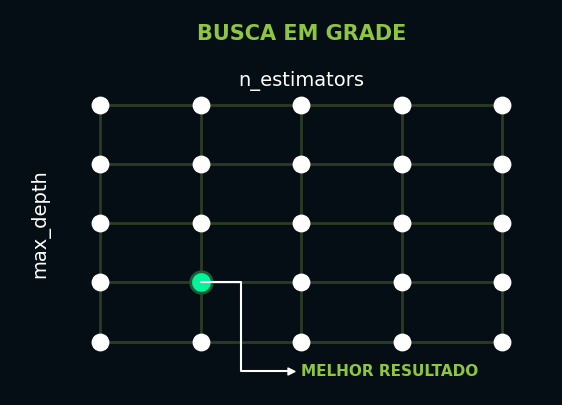

In [13]:
# Importa as bibliotecas necessárias para replicar o design exato gerado no notebook
import matplotlib.pyplot as plt
import numpy as np

# Configura a matriz conceitual de 5x5 pontos para representar os hiperparâmetros
x_indices = np.arange(5)
y_indices = np.arange(5)
X_mesh, Y_mesh = np.meshgrid(x_indices, y_indices)

# Inicializa o gráfico aplicando a paleta de cores azul-escura de fundo do slide
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('#050e14')
ax.set_facecolor('#050e14')

# Desenha as linhas finas da grade com a tonalidade verde/oliva escura sutil
for i in range(len(y_indices)):
    ax.plot(x_indices, [y_indices[i]]*len(x_indices), color='#2d3a22', linewidth=2, zorder=1)
for j in range(len(x_indices)):
    ax.plot([x_indices[j]]*len(y_indices), y_indices, color='#2d3a22', linewidth=2, zorder=1)

# Plota os círculos brancos puros que representam cada combinação testada na busca em grade
ax.scatter(X_mesh, Y_mesh, color='#ffffff', s=140, zorder=2)

# Destaca a combinação ideal com um círculo maior na cor verde-turquesa brilhante e borda escura
ax.scatter(1, 1, color='#00f59b', s=240, edgecolors='#1e5a32', linewidth=2, zorder=3)

# Desenha a linha branca em formato de degrau descendo abaixo da grade (nível -0.5) para liberar o visual
ax.plot([1, 1.4, 1.4, 1.9], [1, 1, -0.5, -0.5], color='white', linewidth=1.5, zorder=4)
ax.scatter(1.9, -0.5, marker='>', color='white', s=25, zorder=5)

# Insere o texto descritivo do melhor resultado reposicionado abaixo da grade sem sobreposição
ax.text(2.0, -0.5, 'MELHOR RESULTADO', color='#8ec641', fontsize=11, weight='bold', va='center')

# Adiciona os títulos textuais imitando perfeitamente o posicionamento do seu print
ax.text(2, 4.4, 'n_estimators', color='#ffffff', fontsize=14, ha='center', va='center')
ax.text(-0.6, 2, 'max_depth', color='#ffffff', fontsize=14, rotation=90, ha='center', va='center')

# Adiciona o título principal "BUSCA EM GRADE" centralizado no topo do gráfico
ax.text(2, 5.2, 'BUSCA EM GRADE', color='#8ec641', fontsize=15, weight='bold', ha='center', va='center')

# Configura os limites de exibição e remove completamente as bordas padrão do Matplotlib
ax.set_xlim(-0.9, 4.5)
ax.set_ylim(-0.9, 5.6)
ax.axis('off')

# Exibe o gráfico finalizado livre de sobreposições com as linhas
plt.show()


In [14]:
# Importa a ferramenta GridSearchCV para realizar a busca exaustiva de hiperparâmetros em grade combinada com validação cruzada
from sklearn.model_selection import GridSearchCV


In [15]:
# Importa a biblioteca NumPy para manipulação numérica avançada e geração de sequências aritmética
import numpy as np

# Cria um dicionário extenso com uma grade de hiperparâmetros (param_grid_dt) para otimizar o modelo de Árvore de Decisão
param_grid_dt = {
    # Testa os critérios Gini e Entropia para medir a pureza e ganho de informação na divisão dos nós
    'criterion':  ['gini', 'entropy'],
    
    # Gera 4 valores inteiros linearmente espaçados entre 6 e 12 para controlar a profundidade máxima da árvore
    'max_depth': np.linspace(6, 12, 4, dtype=int),
    
    # Gera 4 valores de 5 a 20 para definir o número mínimo de amostras necessárias para dividir um nó interno
    'min_samples_split': np.linspace(5, 20, 4, dtype=int),
    
    # Gera 4 valores de 5 a 20 para definir a quantidade mínima de amostras exigidas em cada nó folha (final)
    'min_samples_leaf': np.linspace(5, 20, 4, dtype=int),
    
    # Avalia estratégias matemáticas diferentes (Raiz Quadrada ou Logaritmo de Base 2) para o número máximo de recursos na divisão
    'max_features': ['sqrt', 'log2'],
    
    # Define a estratégia usada para escolher a divisão em cada nó: a melhor divisão possível ('best') ou uma divisão aleatória ('random')
    'splitter': ['best', 'random']
}


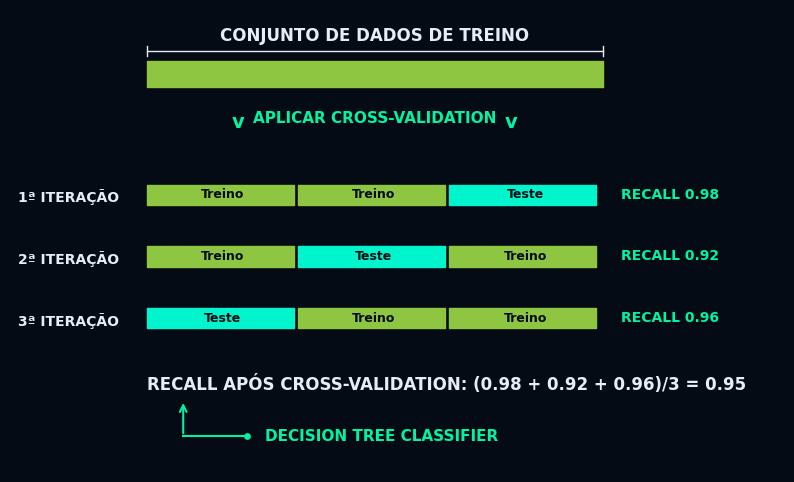

In [16]:
# Importa as bibliotecas necessárias para desenhar o esquema visual de validação cruzada
import matplotlib.pyplot as plt
import numpy as np

# Inicializa os eixos e define a cor escura de fundo exata do slide do curso
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#040b14')
ax.set_facecolor('#040b14')

# Desenha a barra superior representando o conjunto completo de dados de treino original
ax.text(3, 8.2, 'CONJUNTO DE DADOS DE TREINO', color='#e6edf6', fontsize=12, weight='bold', ha='center')
ax.fill_between([0.5, 5.5], [7.3, 7.3], [7.8, 7.8], color='#8ec641')
ax.plot([0.5, 5.5], [8.0, 8.0], color='#e6edf6', linewidth=1)
ax.plot([0.5, 0.5], [7.9, 8.1], color='#e6edf6', linewidth=1)
ax.plot([5.5, 5.5], [7.9, 8.1], color='#e6edf6', linewidth=1)

# Adiciona os indicadores de ação e setas estilizadas para a aplicação do Cross-Validation
ax.text(1.5, 6.5, 'v', color='#02f3a2', fontsize=14, weight='bold', ha='center')
ax.text(3.0, 6.6, 'APLICAR CROSS-VALIDATION', color='#02f3a2', fontsize=11, weight='bold', ha='center')
ax.text(4.5, 6.5, 'v', color='#02f3a2', fontsize=14, weight='bold', ha='center')

# Define a estrutura das 3 iterações (Folds) com a divisão dinâmica de blocos verdes (Treino) e cianos (Teste)
iterations = [
    {'name': '1ª ITERAÇÃO', 'colors': ['#8ec641', '#8ec641', '#00f5cc'], 'scores': 'RECALL 0.98', 'folds': ['Treino', 'Treino', 'Teste']},
    {'name': '2ª ITERAÇÃO', 'colors': ['#8ec641', '#00f5cc', '#8ec641'], 'scores': 'RECALL 0.92', 'folds': ['Treino', 'Teste', 'Treino']},
    {'name': '3ª ITERAÇÃO', 'colors': ['#00f5cc', '#8ec641', '#8ec641'], 'scores': 'RECALL 0.96', 'folds': ['Teste', 'Treino', 'Treino']}
]
y_positions = [5.0, 3.8, 2.6]

# Loop estrutural para renderizar graficamente cada uma das iterações na tela
for idx, it in enumerate(iterations):
    y = y_positions[idx]
    ax.text(0.2, y + 0.15, it['name'], color='#e6edf6', fontsize=10, weight='bold', ha='right', va='center')
    
    for f_idx, fold_type in enumerate(it['folds']):
        x_start = 0.5 + f_idx * 1.66
        x_end = x_start + 1.66
        ax.fill_between([x_start, x_end-0.05], [y, y], [y+0.4, y+0.4], color=it['colors'][f_idx])
        ax.text((x_start + x_end)/2, y+0.2, fold_type, color='#040b14', fontsize=9, weight='bold', ha='center', va='center')
        
    ax.text(5.7, y + 0.2, it['scores'], color='#02f3a2', fontsize=10, weight='bold', ha='left', va='center')

# Escreve a fórmula matemática do cálculo da média final do Recall pós validação cruzada
ax.text(0.5, 1.4, 'RECALL APÓS CROSS-VALIDATION: (0.98 + 0.92 + 0.96)/3 = 0.95', color='#e6edf6', fontsize=12, weight='bold', ha='left')

# Desenha o indicador em L invertido com ponta de seta idêntico ao novo print enviado
ax.plot([1.6, 0.9], [0.5, 0.5], color='#02f3a2', linewidth=1.5)
ax.annotate('', xy=(0.9, 1.2), xytext=(0.9, 0.5),
             arrowprops=dict(arrowstyle="->", color='#02f3a2', lw=1.5, mutation_scale=12))
ax.scatter(1.6, 0.5, color='#02f3a2', s=15, zorder=5)

# Insere o texto do modelo alinhado perfeitamente à direita do ponto conector
ax.text(1.8, 0.5, 'DECISION TREE CLASSIFIER', color='#02f3a2', fontsize=11, weight='bold', va='center')

# Define os limites espaciais dos eixos e remove todas as bordas tradicionais de gráficos
ax.set_xlim(-1, 7.5)
ax.set_ylim(-0.2, 8.8)
ax.axis('off')

# Renderiza o resultado visual perfeito
plt.show()


In [17]:
# Importa a classe StratifiedKFold para criar uma estratégia de validação cruzada estratificada
from sklearn.model_selection import StratifiedKFold

# Configura o validador cruzado com 5 divisões (folds), misturando os dados antes de dividir e usando a semente aleatória fixa
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Instancia o GridSearchCV juntando o estimador (Árvore de Decisão), a grade de hiperparâmetros gigante, a métrica Recall, usando todos os núcleos de processamento (n_jobs=-1) e o validador cruzado definido
dt_grid_search = GridSearchCV(estimator = DecisionTreeClassifier(random_state=RANDOM_STATE),
                              param_grid = param_grid_dt,
                              scoring = "recall",
                              n_jobs = -1,
                              cv = cv)

# Executa a busca exaustiva (Grid Search) com validação cruzada para treinar e encontrar a melhor combinação de parâmetros usando os dados de treino
dt_grid_search.fit(x_treino, y_treino)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': array([ 6, 8, 10, 12]), 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': array([ 5, 10, 15, 20]), ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score...

In [18]:
# Retorna e exibe o dicionário com a melhor combinação de hiperparâmetros encontrada pelo Grid Search após testar todas as opções da grade
dt_grid_search.best_params_


{'criterion': 'gini',
 'max_depth': np.int64(12),
 'max_features': 'sqrt',
 'min_samples_leaf': np.int64(15),
 'min_samples_split': np.int64(5),
 'splitter': 'best'}

In [19]:
# Armazena a tabela com todos os resultados e métricas da validação cruzada em uma nova variável chamada 'df_cv_results_dt'
df_cv_results_dt = pd.DataFrame(dt_grid_search.cv_results_)

# Exibe as 5 primeiras linhas dessa tabela para analisar os tempos de execução e os scores de cada combinação testada
df_cv_results_dt.head()



,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.043647,0.008256,0.007688,0.001405,gini,6,sqrt,5,5,best,"{'criterion': 'gini', 'max_depth': 6, 'max_fea...",0.213608,0.145570,0.205696,0.164557,0.200949,0.186076,0.026336,251
1,0.036648,0.009532,0.007441,0.000635,gini,6,sqrt,5,5,random,"{'criterion': 'gini', 'max_depth': 6, 'max_fea...",0.193038,0.132911,0.132911,0.112342,0.161392,0.146519,0.028013,493
2,0.043853,0.009428,0.007862,0.001272,gini,6,sqrt,5,10,best,"{'criterion': 'gini', 'max_depth': 6, 'max_fea...",0.213608,0.145570,0.205696,0.164557,0.200949,0.186076,0.026336,251
3,0.011641,0.009336,0.005642,0.000964,gini,6,sqrt,5,10,random,"{'criterion': 'gini', 'max_depth': 6, 'max_fea...",0.193038,0.132911,0.132911,0.112342,0.161392,0.146519,0.028013,493
4,0.010139,0.000838,0.005487,0.000606,gini,6,sqrt,5,15,best,"{'criterion': 'gini', 'max_depth': 6, 'max_fea...",0.200949,0.145570,0.180380,0.164557,0.204114,0.179114,0.022093,277


In [20]:
# Localiza e exibe especificamente a linha da tabela que corresponde ao índice do melhor modelo encontrado pelo Grid Search
df_cv_results_dt.loc[[dt_grid_search.best_index_]]


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
208,0.010176,0.000611,0.00347,0.000271,gini,12,sqrt,15,5,best,"{'criterion': 'gini', 'max_depth': 12, 'max_fe...",0.242089,0.324367,0.272152,0.245253,0.232595,0.263291,0.033244,1


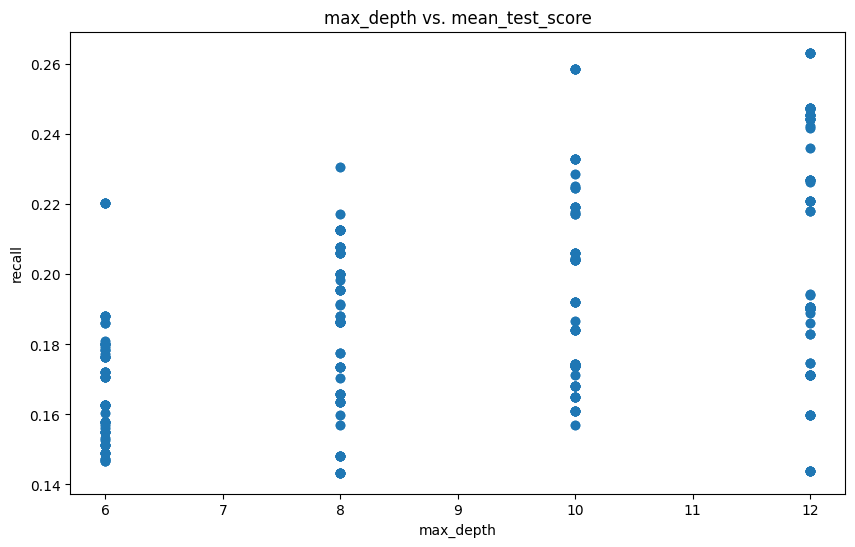

In [26]:
# Importa a biblioteca de visualização de gráficos matplotlib.pyplot
import matplotlib.pyplot as plt

# Configura o tamanho da janela do gráfico para 10 de largura por 6 de altura
plt.figure(figsize=(10, 6))

# Cria um gráfico de dispersão (scatter plot) cruzando os valores testados de max_depth com as respectivas médias de recall obtidas
plt.scatter(
    df_cv_results_dt['param_max_depth'],
    df_cv_results_dt['mean_test_score'],
)

# Define o título principal no topo do gráfico indicando as duas variáveis analisadas
plt.title('max_depth vs. mean_test_score')

# Configura o nome do eixo horizontal (X) para representar a profundidade máxima da árvore
plt.xlabel('max_depth')

# Configura o nome do eixo vertical (Y) para representar a métrica de recall
plt.ylabel('recall')

#  Renderiza e exibe o gráfico construído finalizado na tela do seu notebook
plt.show()


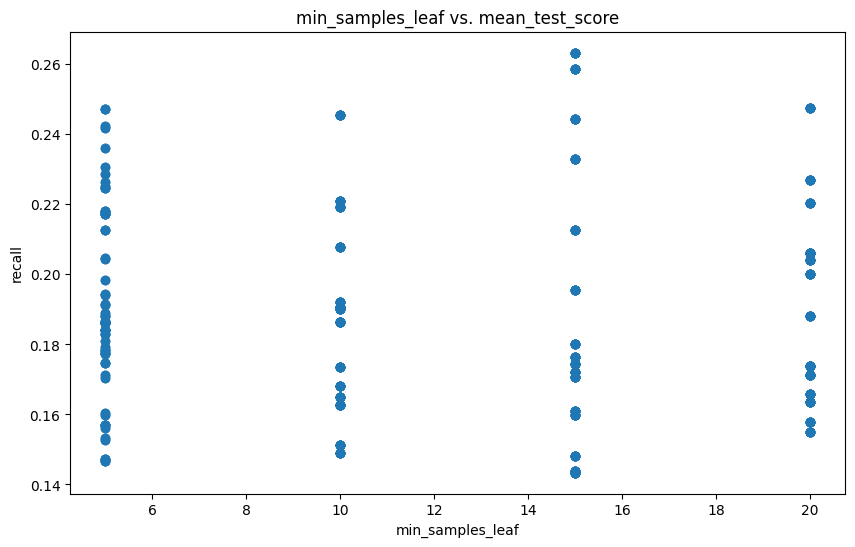

In [22]:
# Inicializa uma nova janela de gráfico com tamanho de 10 por 6 polegadas
plt.figure(figsize=(10, 6))

# Cria um gráfico de dispersão cruzando a quantidade mínima de amostras por folha com a média de recall obtida em cada teste
plt.scatter(
    df_cv_results_dt['param_min_samples_leaf'],
    df_cv_results_dt['mean_test_score'],
)

# Define o título principal do topo do gráfico para identificar a nova relação de variáveis
plt.title('min_samples_leaf vs. mean_test_score')

# Configura o rótulo do eixo horizontal (X) para representar o hiperparâmetro min_samples_leaf
plt.xlabel('min_samples_leaf')

# Configura o rótulo do eixo vertical (Y) para representar a métrica de recall
plt.ylabel('recall')

# Renderiza e exibe o gráfico de dispersão concluído na tela do seu ambiente
plt.show()


In [32]:
# Cria uma sequência de 5 valores inteiros igualmente espaçados de 100 a 300 para testar o limite máximo de iterações do modelo
max_iter = np.linspace(100, 300, 5, dtype=int)

# Define uma lista com 5 valores para o parâmetro de regularização C, variando de forte (0.001) a fraca (10) regularização
c = [0.001, 0.01, 0.1, 1, 10]

# Cria uma lista contendo dois dicionários de grade de hiperparâmetros (param_grid_lr) específicos para otimizar o Pipeline da Regressão Logística
param_grid_lr = [
    # Primeira grade: Testa os solvers 'newton-cg' e 'lbfgs' suportando estritamente a penalidade de regularização L2 (Ridge)
    {
        'logisticregression__solver' : ['newton-cg', 'lbfgs'],
        'logisticregression__penalty' : ['l2'],
        'logisticregression__max_iter' : max_iter,
        'logisticregression__C' : c
    },
    # Segunda grade: Testa o solver 'liblinear' que suporta de forma simultânea as penalidades L1 (Lasso) e L2 (Ridge)
    {
        'logisticregression__solver' : ['liblinear'],
        'logisticregression__penalty' : ['l1', 'l2'],
        'logisticregression__max_iter' : max_iter,
        'logisticregression__C' : c
    },
]


In [ ]:
# Instancia o GridSearchCV para otimizar o Pipeline da Regressão Logística, aplicando a padronização dos dados, a grade param_grid_lr e a validação cruzada estratificada (cv) focando na métrica Recall
lr_grid_search = GridSearchCV(estimator = make_pipeline(StandardScaler(), LogisticRegression(random_state=42)),
                               param_grid = param_grid_lr,
                               scoring = "recall",
                               n_jobs = -1,
                               cv = cv)

# Executa a busca em grade de forma paralela (usando todos os núcleos do processador) ajustando o modelo com os dados de treino
lr_grid_search.fit(x_treino, y_treino)
# Limpa instantaneamente todas as mensagens de texto e avisos acumulados nas saídas das células do VS Code
from IPython.display import clear_output
clear_output()



In [35]:
# Retorna e exibe o dicionário com a combinação ideal de hiperparâmetros encontrada para a Regressão Logística dentro do pipeline
lr_grid_search.best_params_


{'logisticregression__C': 0.001,
 'logisticregression__max_iter': np.int64(100),
 'logisticregression__penalty': 'l2',
 'logisticregression__solver': 'liblinear'}

In [37]:
# Converte o dicionário de resultados da validação cruzada da Regressão Logística em um DataFrame do Pandas chamado 'df_cv_results_lr'
df_cv_results_lr = pd.DataFrame(lr_grid_search.cv_results_)

# Exibe as 5 primeiras linhas dessa tabela para analisar as métricas e tempos de execução de cada combinação testada
df_cv_results_lr.head()


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logisticregression__C,param_logisticregression__max_iter,param_logisticregression__penalty,param_logisticregression__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.012545,0.000998,0.005042,0.000814,0.001,100,l2,newton-cg,"{'logisticregression__C': 0.001, 'logisticregr...",0.102848,0.101266,0.115506,0.088608,0.079114,0.097468,0.012523,86
1,0.007176,0.000786,0.003529,0.000136,0.001,100,l2,lbfgs,"{'logisticregression__C': 0.001, 'logisticregr...",0.102848,0.101266,0.113924,0.087025,0.079114,0.096835,0.012313,91
2,0.011328,0.001416,0.004570,0.000401,0.001,150,l2,newton-cg,"{'logisticregression__C': 0.001, 'logisticregr...",0.102848,0.101266,0.115506,0.088608,0.079114,0.097468,0.012523,86
3,0.009677,0.001138,0.004741,0.000680,0.001,150,l2,lbfgs,"{'logisticregression__C': 0.001, 'logisticregr...",0.102848,0.101266,0.113924,0.087025,0.079114,0.096835,0.012313,91
4,0.013294,0.002060,0.004843,0.000512,0.001,200,l2,newton-cg,"{'logisticregression__C': 0.001, 'logisticregr...",0.102848,0.101266,0.115506,0.088608,0.079114,0.097468,0.012523,86


In [39]:
# Localiza e exibe especificamente a linha da tabela que corresponde ao índice do melhor modelo de Regressão Logística encontrado
df_cv_results_lr.loc[[lr_grid_search.best_index_]]


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logisticregression__C,param_logisticregression__max_iter,param_logisticregression__penalty,param_logisticregression__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
51,0.015162,0.00285,0.007353,0.001695,0.001,100,l2,liblinear,"{'logisticregression__C': 0.001, 'logisticregr...",0.251582,0.254747,0.265823,0.248418,0.235759,0.251266,0.009723,1


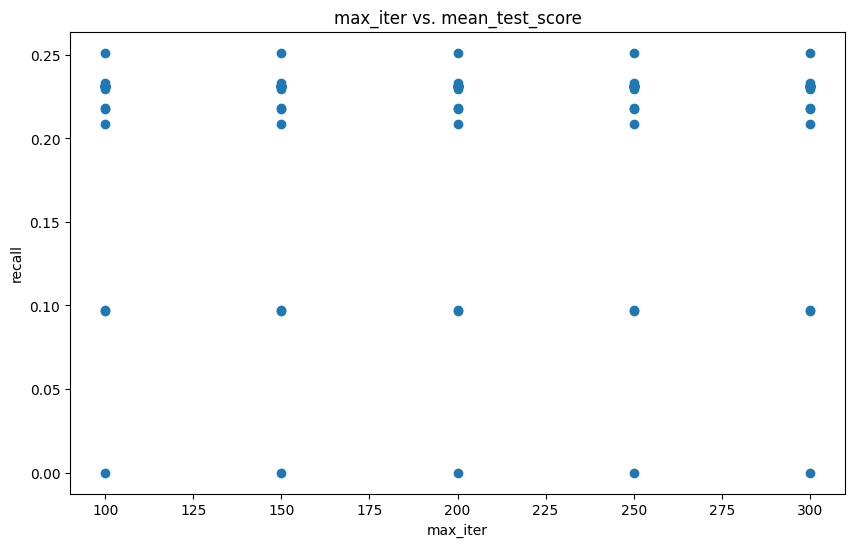

In [41]:
# Configura uma nova janela de gráfico com tamanho de 10 de largura por 6 de altura
plt.figure(figsize=(10, 6))

# Cria um gráfico de dispersão cruzando o limite máximo de iterações da Regressão Logística com as respectivas médias de recall obtidas
plt.scatter(
    df_cv_results_lr['param_logisticregression__max_iter'],
    df_cv_results_lr['mean_test_score'],
)

# Define o título principal no topo para identificar a relação do hiperparâmetro de iteração com o desempenho
plt.title('max_iter vs. mean_test_score')

# Configura o rótulo do eixo horizontal (X) para representar a quantidade máxima de iterações do algoritmo
plt.xlabel('max_iter')

# Configura o rótulo do eixo vertical (Y) para representar a métrica de recall obtida nos testes
plt.ylabel('recall')

# Renderiza e exibe o gráfico de dispersão finalizado na tela do seu notebook
plt.show()


Validação cruzada aninhada

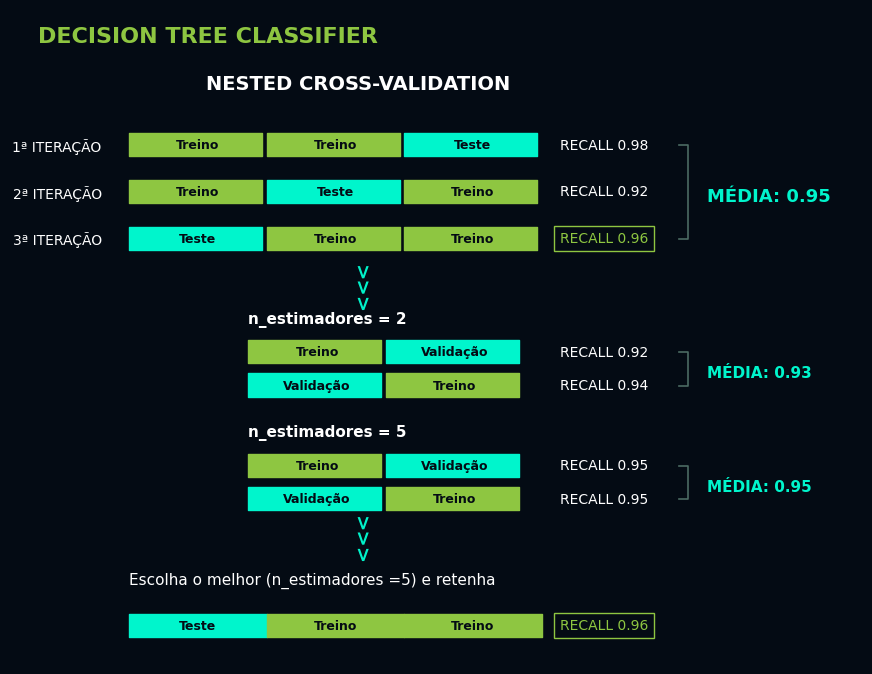

In [54]:
# Importa as bibliotecas necessárias para replicar o fluxograma conceitual de validação cruzada aninhada
import matplotlib.pyplot as plt
import numpy as np

# Configura a janela gráfica e aplica a paleta de cores azul-escura fiel ao slide original do curso
fig, ax = plt.subplots(figsize=(11, 8.5))
fig.patch.set_facecolor('#040b14')
ax.set_facecolor('#040b14')

# Adiciona os títulos principais e o cabeçalho estrutural idênticos ao print
ax.text(-0.5, 9.5, 'DECISION TREE CLASSIFIER', color='#8ec641', fontsize=16, weight='bold', ha='left')
ax.text(3.0, 8.8, 'NESTED CROSS-VALIDATION', color='#ffffff', fontsize=14, weight='bold', ha='center')

# Monta a estrutura da grade externa (Outer Loop) mantendo os nomes ordinais das iterações
outer_iters = [
    {'name': '1ª ITERAÇÃO', 'folds': ['Treino', 'Treino', 'Teste'], 'colors': ['#8ec641', '#8ec641', '#00f5cc'], 'score': 'RECALL 0.98'},
    {'name': '2ª ITERAÇÃO', 'folds': ['Treino', 'Teste', 'Treino'], 'colors': ['#8ec641', '#00f5cc', '#8ec641'], 'score': 'RECALL 0.92'},
    {'name': '3ª ITERAÇÃO', 'folds': ['Teste', 'Treino', 'Treino'], 'colors': ['#00f5cc', '#8ec641', '#8ec641'], 'score': 'RECALL 0.96'}
]
y_outer = [7.8, 7.1, 6.4]

for idx, it in enumerate(outer_iters):
    y = y_outer[idx]
    ax.text(0.2, y + 0.15, it['name'], color='#ffffff', fontsize=10, ha='right', va='center')
    for f_idx, fold_name in enumerate(it['folds']):
        x_start = 0.5 + f_idx * 1.5
        x_end = x_start + 1.5
        ax.fill_between([x_start, x_end-0.05], [y, y], [y+0.35, y+0.35], color=it['colors'][f_idx])
        ax.text((x_start+x_end)/2, y+0.17, fold_name, color='#040b14', fontsize=9, weight='bold', ha='center', va='center')
    
    if idx == 2:
        ax.text(5.2, y + 0.17, it['score'], color='#8ec641', fontsize=10, ha='left', va='center',
                bbox=dict(facecolor='none', edgecolor='#8ec641', pad=4, linewidth=1))
    else:
        ax.text(5.2, y + 0.17, it['score'], color='#ffffff', fontsize=10, ha='left', va='center')

# Desenha o primeiro colchete e as médias ajustadas
ax.text(6.8, 7.2, 'MÉDIA: 0.95', color='#00f5cc', fontsize=13, weight='bold', va='center')
ax.plot([6.5, 6.6, 6.6, 6.5], [7.97, 7.97, 6.57, 6.57], color='#4b6b63', linewidth=1.2)

# AJUSTE: Seta superior movida para Y=5.5 para liberar espaço do bloco de cima
ax.text(3.0, 5.5, '>>>', color='#00f5cc', fontsize=14, weight='bold', ha='center', rotation=270)

# Constrói a simulação da grade interna (Inner Loop) para o parâmetro n_estimadores = 2
ax.text(1.8, 5.3, 'n_estimadores = 2', color='#ffffff', fontsize=11, weight='bold', ha='left')
inner_2 = [
    {'folds': ['Treino', 'Validação'], 'colors': ['#8ec641', '#00f5cc'], 'score': 'RECALL 0.92'},
    {'folds': ['Validação', 'Treino'], 'colors': ['#00f5cc', '#8ec641'], 'score': 'RECALL 0.94'}
]
y_inner_2 = [4.7, 4.2]

for idx, it in enumerate(inner_2):
    y = y_inner_2[idx]
    for f_idx, fold_name in enumerate(it['folds']):
        x_start = 1.8 + f_idx * 1.5
        x_end = x_start + 1.5
        ax.fill_between([x_start, x_end-0.05], [y, y], [y+0.35, y+0.35], color=it['colors'][f_idx])
        ax.text((x_start+x_end)/2, y+0.17, fold_name, color='#040b14', fontsize=9, weight='bold', ha='center', va='center')
    ax.text(5.2, y + 0.17, it['score'], color='#ffffff', fontsize=10, ha='left', va='center')

# Desenha o segundo colchete ajustado
ax.text(6.8, 4.55, 'MÉDIA: 0.93', color='#00f5cc', fontsize=11, weight='bold', va='center')
ax.plot([6.5, 6.6, 6.6, 6.5], [4.87, 4.87, 4.37, 4.37], color='#4b6b63', linewidth=1.2)

# Constrói a simulação da grade interna (Inner Loop) para o parâmetro n_estimadores = 5
ax.text(1.8, 3.6, 'n_estimadores = 5', color='#ffffff', fontsize=11, weight='bold', ha='left')
inner_5 = [
    {'folds': ['Treino', 'Validação'], 'colors': ['#8ec641', '#00f5cc'], 'score': 'RECALL 0.95'},
    {'folds': ['Validação', 'Treino'], 'colors': ['#00f5cc', '#8ec641'], 'score': 'RECALL 0.95'}
]
y_inner_5 = [3.0, 2.5]

for idx, it in enumerate(inner_5):
    y = y_inner_5[idx]
    for f_idx, fold_name in enumerate(it['folds']):
        x_start = 1.8 + f_idx * 1.5
        x_end = x_start + 1.5
        ax.fill_between([x_start, x_end-0.05], [y, y], [y+0.35, y+0.35], color=it['colors'][f_idx])
        ax.text((x_start+x_end)/2, y+0.17, fold_name, color='#040b14', fontsize=9, weight='bold', ha='center', va='center')
    ax.text(5.2, y + 0.17, it['score'], color='#ffffff', fontsize=10, ha='left', va='center')

# Desenha o terceiro colchete ajustado
ax.text(6.8, 2.85, 'MÉDIA: 0.95', color='#00f5cc', fontsize=11, weight='bold', va='center')
ax.plot([6.5, 6.6, 6.6, 6.5], [3.17, 3.17, 2.67, 2.67], color='#4b6b63', linewidth=1.2)

# AJUSTE: Seta inferior movida para Y=1.75 para liberar espaço abaixo do bloco de n_estimadores=5
ax.text(3.0, 1.75, '>>>', color='#00f5cc', fontsize=14, weight='bold', ha='center', rotation=270)
ax.text(0.5, 1.4, 'Escolha o melhor (n_estimadores =5) e retenha', color='#ffffff', fontsize=11, ha='left')

# Resultado retido final
ax.fill_between([0.5, 2.0], [0.6, 0.6], [0.95, 0.95], color='#00f5cc')
ax.text(1.25, 0.77, 'Teste', color='#040b14', fontsize=9, weight='bold', ha='center', va='center')
ax.fill_between([2.0, 3.5], [0.6, 0.6], [0.95, 0.95], color='#8ec641')
ax.text(2.75, 0.77, 'Treino', color='#040b14', fontsize=9, weight='bold', ha='center', va='center')
ax.fill_between([3.5, 5.0], [0.6, 0.6], [0.95, 0.95], color='#8ec641')
ax.text(4.25, 0.77, 'Treino', color='#040b14', fontsize=9, weight='bold', ha='center', va='center')

ax.text(5.2, 0.77, 'RECALL 0.96', color='#8ec641', fontsize=10, ha='left', va='center',
        bbox=dict(facecolor='none', edgecolor='#8ec641', pad=4, linewidth=1))

# Oculta contornos e exibe o gráfico finalizado
ax.set_xlim(-0.8, 8.5)
ax.set_ylim(0.2, 10.0)
ax.axis('off')
plt.show()


In [55]:
# Configura o validador cruzado interno (Inner Loop) mantendo o número padrão de folds (5) para buscar os hiperparâmetros
inner_cv = StratifiedKFold(shuffle=True, random_state=RANDOM_STATE)

# Configura o validador cruzado externo (Outer Loop) com 3 divisões para avaliar a capacidade de generalização do modelo
outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


In [56]:
# Importa a função cross_val_score para realizar a validação cruzada externa do processo aninhada
from sklearn.model_selection import cross_val_score

# Configura o GridSearchCV interno encarregado de buscar os melhores hiperparâmetros na base de validação (cv=inner_cv)
dt_nested_gs = GridSearchCV(estimator = DecisionTreeClassifier(random_state=RANDOM_STATE),
                                         param_grid = param_grid_dt,
                                         scoring = "recall",
                                         n_jobs = -1,
                                         cv = inner_cv
                                         )

# Executa o processo completo de Validação Cruzada Aninhada (Nested Cross-Validation), avaliando o Grid Search com a divisão de dados externa (cv=outer_cv)
dt_nested_scores = cross_val_score(dt_nested_gs, x_treino, y_treino, cv=outer_cv)


In [57]:
# Imprime o vetor contendo a métrica de Recall obtida em cada uma das partições (folds) do loop externo do Cross-Validation
print(f'resultado de cada iteração do cv externo: {dt_nested_scores}')

# Calcula e exibe a média aritmética final obtida pelo modelo considerando todas as iterações aninhadas
print(f'média: {dt_nested_scores.mean()}')


resultado de cada iteração do cv externo: [0.23646724 0.24762808 0.20512821]
média: 0.2297411750289676


Busca aleatória para o Decision Tree Classifier

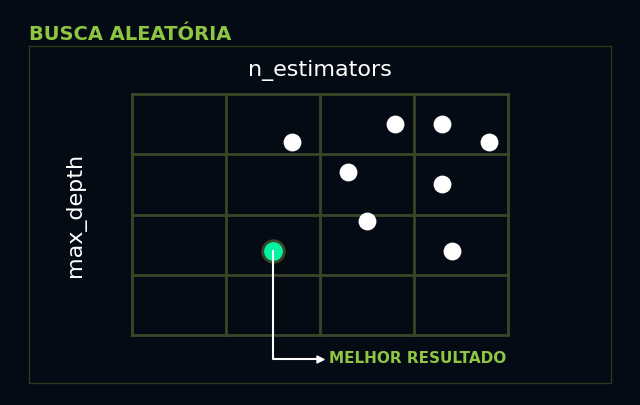

In [58]:
# Importa as bibliotecas necessárias para replicar o design exato do slide de Busca Aleatória
import matplotlib.pyplot as plt
import numpy as np

# Inicializa o gráfico aplicando a paleta de cores azul-escura fiel ao slide original
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#040b14')
ax.set_facecolor('#040b14')

# Desenha as linhas finas da grade com a tonalidade verde/oliva escura sutil
x_lines = [0, 1, 2, 3, 4]
y_lines = [0, 1, 2, 3, 4]

for y in y_lines:
    ax.plot(x_lines, [y]*len(x_lines), color='#3a4626', linewidth=2, zorder=1)
for x in x_lines:
    ax.plot([x]*len(y_lines), y_lines, color='#3a4626', linewidth=2, zorder=1)

# Plota as bolinhas brancas puras de forma espalhada e aleatória (fora das intersecções)
random_points = [
    (1.7, 3.2), (2.3, 2.7), (2.8, 3.5), (3.3, 3.5), 
    (3.8, 3.2), (3.3, 2.5), (2.5, 1.9), (3.4, 1.4)
]
for px, py in random_points:
    ax.scatter(px, py, color='#ffffff', s=140, zorder=2)

# Destaca a melhor combinação aleatória com um círculo maior em verde-turquesa brilhante
best_x, best_y = 1.5, 1.4
ax.scatter(best_x, best_y, color='#02f3a2', s=240, edgecolors='#3a4626', linewidth=2, zorder=3)

# Desenha a linha guia em formato de L que desce do ponto verde e aponta para o texto com uma seta
ax.plot([best_x, best_x, best_x + 0.5], [best_y, -0.4, -0.4], color='white', linewidth=1.5, zorder=4)
ax.scatter(best_x + 0.5, -0.4, marker='>', color='white', s=25, zorder=5)

# Insere o texto "MELHOR RESULTADO" em verde-alface alinhado à direita da seta
ax.text(best_x + 0.6, -0.4, 'MELHOR RESULTADO', color='#8ec641', fontsize=11, weight='bold', va='center')

# Adiciona os títulos textuais dos hiperparâmetros simulando o slide
ax.text(2, 4.4, 'n_estimators', color='#ffffff', fontsize=16, ha='center', va='center')
ax.text(-0.6, 2, 'max_depth', color='#ffffff', fontsize=16, rotation=90, ha='center', va='center')

# Adiciona o título principal "BUSCA ALEATÓRIA" no canto superior esquerdo
ax.text(-1.1, 5.0, 'BUSCA ALEATÓRIA', color='#8ec641', fontsize=14, weight='bold', ha='left', va='center')

# Desenha a moldura retangular fina e discreta em torno dos elementos do slide
ax.plot([-1.1, 5.1, 5.1, -1.1, -1.1], [-0.8, -0.8, 4.8, 4.8, -0.8], color='#2d371e', linewidth=1, zorder=0)

# Configura as margens de exibição e oculta as bordas padrão do Matplotlib
ax.set_xlim(-1.3, 5.3)
ax.set_ylim(-1.0, 5.4)
ax.axis('off')

# Exibe o gráfico idêntico ao slide de Busca Aleatória
plt.show()


In [59]:
from sklearn.model_selection import RandomizedSearchCV

In [69]:
# Instancia o RandomizedSearchCV para realizar a busca aleatória de hiperparâmetros, sorteando 100 combinações diferentes (n_iter=100) com validação cruzada interna
rs_dt = RandomizedSearchCV(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
            param_distributions=param_grid_dt,
            n_iter=100,
            scoring='recall',
            n_jobs=-1,
            cv=inner_cv,
            random_state=RANDOM_STATE)

# Executa o processo de Validação Cruzada Aninhada (Nested Cross-Validation), avaliando o algoritmo de busca aleatória no loop externo (cv=outer_cv)
rs_dt_nested_scores = cross_val_score(rs_dt, x_treino, y_treino, cv=outer_cv)


In [70]:
# Imprime a lista com o valor de Recall alcançado em cada uma das partições (folds) do loop externo usando busca aleatória
print(f'resultado de cada iteração do cv externo: {rs_dt_nested_scores}')

# Calcula e exibe a média final das métricas de Recall obtidas em todas as rodadas da validação aninhada aleatória
print(f'média: {rs_dt_nested_scores.mean()}')


resultado de cada iteração do cv externo: [0.23646724 0.18975332 0.21272555]
média: 0.21298203440307595


In [71]:
# Executa o treinamento e a busca pelos melhores hiperparâmetros
# Ele testa combinações aleatórias do seu grid usando validação cruzada
rs_dt.fit(x_treino, y_treino)

# Retorna um dicionário com a melhor combinação de parâmetros encontrada
# Útil para entender como o modelo tomou as melhores decisões (ex: profundidade da árvore)
rs_dt.best_params_


{'splitter': 'best',
 'min_samples_split': np.int64(5),
 'min_samples_leaf': np.int64(15),
 'max_features': 'sqrt',
 'max_depth': np.int64(12),
 'criterion': 'gini'}

In [75]:
# Instancia o RandomizedSearchCV utilizando um pipeline que padroniza os dados e aplica a Regressão Logística
# A padronização garante que os recursos fiquem na mesma escala, o que é essencial para o algoritmo linear
rs_lr = RandomizedSearchCV(estimator=make_pipeline(StandardScaler(), LogisticRegression()),
        param_distributions=param_grid_lr, # Distribuição de parâmetros a ser testada na busca aleatória
        n_iter=50,                          # Define a quantidade de combinações de parâmetros que serão testadas
        scoring='recall',                   # Otimiza o modelo focando em reduzir os Falsos Negativos
        n_jobs=-1,                          # Utiliza todos os processadores disponíveis para acelerar o cálculo
        cv=inner_cv,                        # Validação cruzada interna para selecionar os melhores hiperparâmetros
        random_state=RANDOM_STATE)          # Garante a reprodutibilidade dos resultados obtidos na busca
        
# Executa a validação cruzada externa para avaliar a capacidade de generalização do pipeline configurado
# Essa etapa simula como o processo completo se comportaria com dados totalmente novos
rs_lr_nested_scores = cross_val_score(rs_lr, x_treino, y_treino, cv=outer_cv)

# Exibe o valor da métrica Recall obtido em cada uma das partições do teste externo
print(f'resultado de cada iteração do cv externo: {rs_lr_nested_scores}')

# Calcula e exibe o desempenho médio final do modelo considerando todas as rodadas externas
print(f'média: {rs_lr_nested_scores.mean()}')



resultado de cada iteração do cv externo: [0.24691358 0.27703985 0.2374169 ]
média: 0.2537901108426093


In [76]:
# Executa o treinamento do pipeline e a busca pelos melhores hiperparâmetros da Regressão Logística
# Ele aplica a padronização e testa as combinações aleatórias na base de treino completa
rs_lr.fit(x_treino, y_treino)

# Retorna os melhores parâmetros específicos encontrados para o modelo de Regressão Logística
# Útil para conferir os coeficientes de regularização e penalidades que trouxeram o melhor Recall
rs_lr.best_params_


{'logisticregression__solver': 'liblinear',
 'logisticregression__penalty': 'l2',
 'logisticregression__max_iter': np.int64(150),
 'logisticregression__C': 0.001}